In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("BI_noB1B10_2017_test_pixel.csv")
df.head()

,ID,Region,tillClass,B10_p0_sow,B10_p100_sow,B10_p25_sow,B10_p50_sow,B10_p75_sow,B11_p0_sow,B11_p100_sow,...,SNDVI_p0_peak,SNDVI_p100_peak,SNDVI_p25_peak,SNDVI_p50_peak,SNDVI_p75_peak,STI_p0_peak,STI_p100_peak,STI_p25_peak,STI_p50_peak,STI_p75_peak
0,1,Bihar,ZT,-0.924913,3.029043,-0.723106,-0.209337,0.380373,0.124338,0.285878,...,0.109090,0.492909,0.238458,0.342152,0.433814,1.160622,1.510029,1.253969,1.298421,1.487457
1,1,Bihar,ZT,-1.041067,0.380373,-0.790673,-0.597369,0.137131,0.143189,0.301672,...,0.132488,0.603815,0.282442,0.409026,0.505459,1.213439,1.755575,1.366333,1.507493,1.680208
2,1,Bihar,ZT,-0.924913,3.029043,-0.723106,-0.209337,0.380373,0.131779,0.286525,...,0.110585,0.460611,0.258122,0.323402,0.395251,1.171866,1.500081,1.267745,1.335346,1.486752
3,1,Bihar,ZT,-0.924913,11.459722,-0.723106,-0.018267,0.427072,0.133647,0.407353,...,0.105139,0.458611,0.245265,0.315298,0.388134,1.155592,1.484443,1.241905,1.283196,1.411449
4,1,Bihar,ZT,-0.924913,3.029043,-0.723106,-0.209337,0.380373,0.124338,0.285878,...,0.099935,0.459526,0.248090,0.324698,0.403208,1.160622,1.510029,1.253969,1.298421,1.487457


In [4]:
from sklearn.preprocessing import LabelEncoder

# Create the encoder
le = LabelEncoder()

# Fit and transform the target column
y = le.fit_transform(df['tillClass'])

print(y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [5]:
X = df.drop(['Region'], axis='columns')
selected_features = ['NDVI_p50_sow','SNDVI_p50_sow','NDTI_p50_sow','CRC_p50_sow','GCVI_p50_sow','STI_p50_sow','B10_p50_sow','B11_p50_sow']
X = df[selected_features]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
model = RandomForestClassifier(n_estimators=600)
model.fit(X_train, y_train)

,n_estimators,600
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
model.score(X_test,y_test)

0.953125

In [14]:
y_predicted = model.predict(X_test)

In [15]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
cm

array([[27,  2],
       [ 1, 34]])

Text(95.72222222222221, 0.5, 'Truth')

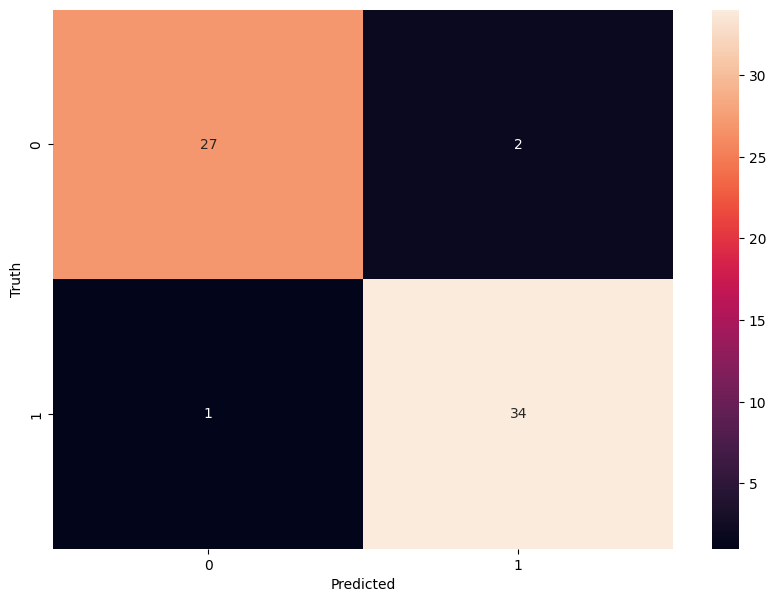

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')